# Phase 1 — Baseline Empirical Study

This notebook covers:
1. Dataset characterisation
2. Bias analysis — surface and structural
3. `KNNClassifierFast` — vectorised implementation
4. `KNNOptK` — the Phase 1 baseline
5. Phase 1 conclusions

Results are saved to `results/tables/` and loaded by `report.ipynb`.  
Algorithm theory is in `algorithm_design.ipynb`.

---
## 1. Setup

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from src.utils.config import load_config, get_project_root
from src.data.loader import load_all_datasets
from src.data.preprocessing import binarise_labels, remove_constant_features, standardise
from src.algorithms import KNNClassifier, KNNClassifierFast, KNNOptK
from src.evaluation.metrics import compute_all_metrics

cfg = load_config()
SEED = cfg["random_seed"]
rng = np.random.default_rng(SEED)

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

FIG_DIR = get_project_root() / cfg["paths"]["results_figures"]
TAB_DIR = get_project_root() / cfg["paths"]["results_tables"]
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print(f"CV: {cfg['evaluation']['cv_folds']}-fold × {cfg['evaluation']['n_repetitions']} repeat(s)")

Setup complete.
CV: 10-fold × 1 repeat(s)


In [2]:
datasets = load_all_datasets()
print(f'Loaded {len(datasets)} datasets.')

/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Loaded 49 datasets.


/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


---
## 2. Dataset Characterisation

Summary statistics across the benchmark suite: number of samples, features, and imbalance ratio (IR = N_maj / N_min).

In [3]:
# Dataset summary table
rows = []
for ds in datasets:
    y = binarise_labels(ds.y)
    counts = np.bincount(y)
    ir = counts[0] / counts[1] if counts[1] > 0 else float('inf')
    rows.append({"dataset": ds.name, "n_samples": len(y), "n_features": ds.X.shape[1],
                 "n_majority": counts[0], "n_minority": counts[1], "IR": round(ir, 2)})

summary_df = pd.DataFrame(rows).sort_values("IR")
summary_df.to_csv(TAB_DIR / "dataset_summary.csv", index=False)
summary_df

,dataset,n_samples,n_features,n_majority,n_minority,IR
4,dataset_1014_analcatdata_dmft,797,7,642,155,4.14
30,dataset_867_visualizing_livestock,130,31,105,25,4.20
31,dataset_875_analcatdata_chlamydia,100,17,81,19,4.26
16,dataset_1061_ar4,107,29,87,20,4.35
20,dataset_312_scene,2407,299,1976,431,4.58
2,dataset_1004_synthetic_control,600,60,500,100,5.00
43,dataset_976_JapaneseVowels,9961,14,8347,1614,5.17
47,dataset_987_collins,500,22,420,80,5.25
32,dataset_940_water-treatment,527,36,447,80,5.59
17,dataset_1064_ar6,101,29,86,15,5.73


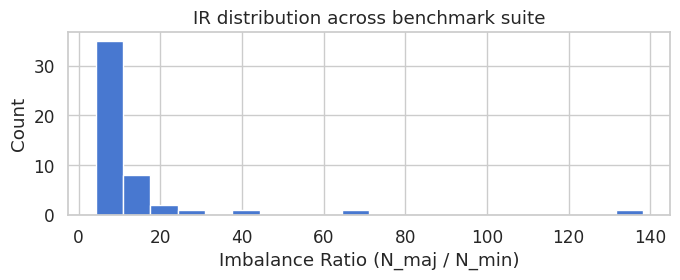

In [4]:
# IR distribution
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(summary_df["IR"], bins=20, edgecolor="white")
ax.set(xlabel="Imbalance Ratio (N_maj / N_min)", ylabel="Count", title="IR distribution across benchmark suite")
plt.tight_layout()
plt.savefig(FIG_DIR / "ir_distribution.png", dpi=150)
plt.show()

---
## 3. Bias Analysis

### 3.1 Surface bias — performance degrades with IR

The simplest way to see the bias: run KNN with a fixed k and plot performance against IR.
We use `KNNOptK` here (see Section 4) so the k choice is not a confound — any degradation is
attributable to imbalance, not to a bad k.

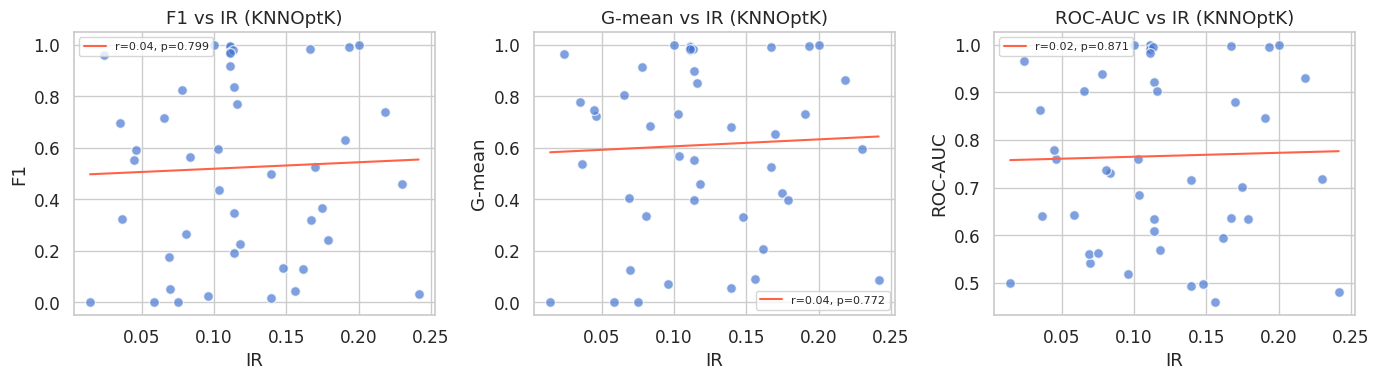

In [5]:
# Load KNNOptK results (generated in Section 4 — run that section first, then re-run this)
_optk_cache = TAB_DIR / "opt_k_raw.csv"
if _optk_cache.exists():
    opt_k_df = pd.read_csv(_optk_cache)
    per_ds = opt_k_df.groupby("dataset")[["IR", "f1", "geometric_mean", "roc_auc"]].mean().reset_index()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (col, label) in zip(axes, [("f1", "F1"), ("geometric_mean", "G-mean"), ("roc_auc", "ROC-AUC")]):
        ax.scatter(per_ds["IR"], per_ds[col], alpha=0.7, edgecolors="white", s=50)
        slope, intercept, r, p, _ = sp_stats.linregress(per_ds["IR"], per_ds[col])
        x_line = np.linspace(per_ds["IR"].min(), per_ds["IR"].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color="tomato", lw=1.5, label=f"r={r:.2f}, p={p:.3f}")
        ax.set(xlabel="IR", ylabel=label, title=f"{label} vs IR (KNNOptK)")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ir_vs_performance.png", dpi=150)
    plt.show()
else:
    print("Run Section 4 (KNNOptK) first, then re-run this cell.")

### 3.2 Structural bias — why even a locally adaptive k is not enough

#### First direction: fix k globally

The natural first reaction to the bias is to blame the choice of k. With a large k the neighbourhood swells and gets flooded with majority points simply because they are more numerous. So the first fix is `KNNOptK`: select k by cross-validation to find the value that works best across the dataset as a whole. It helps — k=1 is chosen in ~62% of folds — but the scatter in 3.1 shows performance still degrades with IR. A globally optimal k is not sufficient.

#### Second direction: adapt k per query point

The next hypothesis is that a *global* k is too coarse. Different regions of the feature space have different local class distributions — near a minority cluster the right k might be small, near a sparse boundary region it might be large. So the logical next step is to make k depend on the local structure around each query point $x$: a **locally adaptive k**.

We explored this direction with topology-based methods (`KNNAdaptiveTopo`), which use persistent homology to classify the local neighbourhood into one of four structural cases and select k accordingly (and other aproaches with entropy and eigenvallues). These approaches did yield meaningful improvements over `KNNOptK`. But they were still not as good as what we eventually found — which suggests that local k adaptation, while helpful, is not the right frame for the problem.

#### The structural insight: the problem is not k

The reason neither a globally optimal nor a locally adaptive k fully solves the problem is that the issue is not *how many* neighbours we look at — it is *how we compare* the two classes once we have the neighbours. Even with k=1 (the most local possible), standard KNN is making a fundamentally unfair comparison.

To see why, we need to understand what "rank" means here.

**What rank means.** When KNN classifies a query point $x$, it computes the distance from $x$ to every training point and sorts them from closest to furthest — separately for each class:

- **Minority rank 1** — the single closest minority training point to $x$; distance $d_1^\text{min}(x)$
- **Minority rank 2** — the second closest minority training point; distance $d_2^\text{min}(x)$; and so on
- **Majority rank 1** — the single closest majority training point; distance $d_1^\text{maj}(x)$
- **Majority rank 2** — the second closest majority training point; and so on

Rank $k$ is simply position $k$ in the distance-sorted list for that class.

**The unfair comparison.** Standard KNN with $k=1$ asks: *is the closest minority point closer than the closest majority point?* — i.e. does $d_1^\text{min}(x) < d_1^\text{maj}(x)$? This is **minority rank-1 vs majority rank-1**.

This looks symmetric, but it is not. Majority training points are denser in space because there are simply more of them spread across the same region. So majority rank-1 tends to be close to any query point by sheer density, while minority rank-1 tends to be further away for the same reason. No matter how well we adapt k, as long as we compare the same rank across both classes we are comparing different things.

**Quantifying the effect.** Under a homogeneous Poisson process, the expected distance to the $k$-th nearest neighbour of class $c$ in $d$ dimensions scales as:

$$\mathbb{E}[d_k^c(x)] \propto \left(\frac{k}{\lambda_c}\right)^{1/d}$$

where $\lambda_c$ is the spatial density of class $c$. With $\lambda_\text{maj}/\lambda_\text{min} = N_\text{maj}/N_\text{min} = r$, comparing at rank 1:

$$\frac{\mathbb{E}[d_1^\text{min}]}{\mathbb{E}[d_1^\text{maj}]} = r^{1/d}$$

For $r=10$ in 2D this is $\approx 3.2\times$ — the nearest minority point is on average 3× further away than the nearest majority point, purely due to density, not geometry. The plot below confirms this empirically.

#### The fair single comparison

To compare like with like we need the majority rank $k_\text{eff}$ whose expected distance matches that of minority rank-1:

$$\mathbb{E}[d_1^\text{min}(x)] = \mathbb{E}[d_{k_\text{eff}}^\text{maj}(x)]
\implies \left(\frac{1}{\lambda_\text{min}}\right)^{1/d} = \left(\frac{k_\text{eff}}{\lambda_\text{maj}}\right)^{1/d}
\implies k_\text{eff} = r$$

In plain terms: instead of asking "is the closest minority point closer than the **1st** closest majority point?", we ask "is the closest minority point closer than the **$r$-th** closest majority point?" Only then are both sides expected to be at the same distance under the null hypothesis of equal geometry.

#### Multiple fair comparisons — the voting scheme

A single comparison (minority rank-1 vs majority rank-$r$) is noisy. KNNFairRank reduces this noise by casting **multiple fair votes** and taking the majority decision.

The fairness argument scales: minority rank-2 is expected at the same distance as majority rank-$2r$, minority rank-3 at the same distance as majority rank-$3r$, and so on. For each vote $i = 1, 2, \ldots, n_\text{votes}$:

$$\text{vote}_i = \begin{cases} \text{minority} & \text{if } d_i^\text{min}(x) < d_{i \cdot r}^\text{maj}(x) \\ \text{majority} & \text{otherwise} \end{cases}$$

The final prediction is whichever class wins more votes. Each individual comparison is fair by the density argument; aggregating them makes the decision more stable. The full derivation and variants are in `algorithm_design.ipynb §2`.

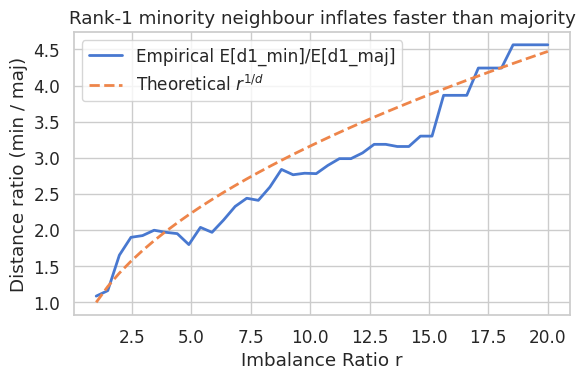

In [6]:
# Synthetic illustration: expected distance to rank-1 neighbour vs IR
# Shows how the minority rank-1 distance inflates relative to majority rank-1 as IR grows

def expected_rank1_distance_ratio(ir_values, d=2, n_maj=200):
    """Empirical E[d1_min] / E[d1_maj] as a function of IR on a 2D Poisson dataset."""
    ratios = []
    for ir in ir_values:
        n_min = max(int(n_maj / ir), 5)
        rng_local = np.random.default_rng(0)
        X_maj = rng_local.uniform(0, 1, size=(n_maj, d))
        X_min = rng_local.uniform(0, 1, size=(n_min, d))

        # For 50 random query points, compute rank-1 distance to each class
        queries = rng_local.uniform(0, 1, size=(50, d))
        d_min = np.sort(np.linalg.norm(queries[:, None, :] - X_min[None, :, :], axis=2), axis=1)[:, 0]
        d_maj = np.sort(np.linalg.norm(queries[:, None, :] - X_maj[None, :, :], axis=2), axis=1)[:, 0]
        ratios.append(np.mean(d_min) / np.mean(d_maj))
    return ratios

ir_vals = np.linspace(1.0, 20.0, 40)
empirical = expected_rank1_distance_ratio(ir_vals)
theoretical = ir_vals ** (1/2)  # r^(1/d), d=2

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ir_vals, empirical, label="Empirical E[d1_min]/E[d1_maj]", lw=2)
ax.plot(ir_vals, theoretical, label=r"Theoretical $r^{1/d}$", lw=2, ls="--")
ax.set(xlabel="Imbalance Ratio r", ylabel="Distance ratio (min / maj)",
       title="Rank-1 minority neighbour inflates faster than majority")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "rank1_distance_ratio.png", dpi=150)
plt.show()

### 3.3 Visualising the decision boundary shift

A 2D synthetic experiment confirms the structural bias visually: even with a well-separated
minority cluster, the KNN decision boundary is pushed away from the minority class as IR grows.

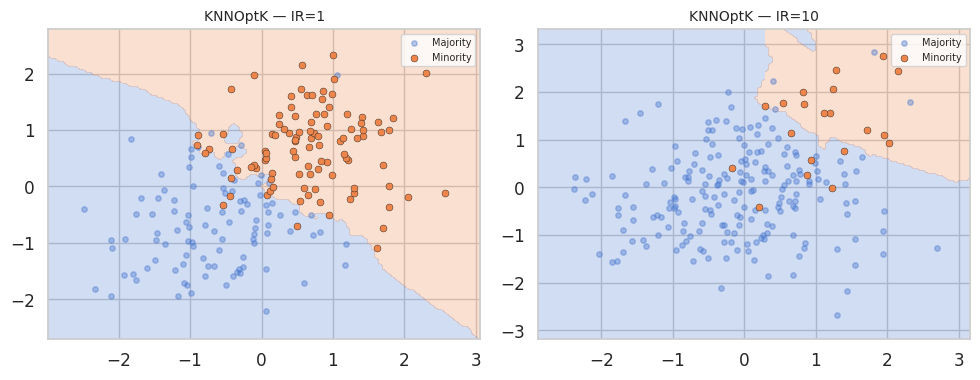

In [7]:
# Synthetic 2D: decision boundary with IR = 1 vs IR = 10
def make_imbalanced_2d(n_maj, n_min, seed=42):
    rng_l = np.random.default_rng(seed)
    X_maj = rng_l.multivariate_normal([0, 0], [[1, 0], [0, 1]], n_maj)
    X_min = rng_l.multivariate_normal([1.5, 1.5], [[0.6, 0], [0, 0.6]], n_min)
    return np.vstack([X_maj, X_min]), np.array([0]*n_maj + [1]*n_min)

def plot_boundary(ax, clf, X, y, title):
    h = 0.05
    x0, x1 = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y0, y1 = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x0, x1, h), np.arange(y0, y1, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, levels=[-0.5, 0.5, 1.5], colors=["#4878d0", "#ee854a"])
    ax.scatter(*X[y==0].T, c="#4878d0", s=15, alpha=0.4, label="Majority")
    ax.scatter(*X[y==1].T, c="#ee854a", s=25, edgecolors="k", lw=0.3, label="Minority")
    ax.set_title(title, fontsize=10); ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (n_maj, n_min, label) in zip(axes, [(100, 100, "IR=1"), (200, 20, "IR=10")]):
    X, y = make_imbalanced_2d(n_maj, n_min)
    X_s = StandardScaler().fit_transform(X)
    # Use KNNOptK so k is data-driven, not arbitrary
    clf = KNNOptK(); clf.fit(X_s, y)
    plot_boundary(ax, clf, X_s, y, f"KNNOptK — {label}")
plt.tight_layout()
plt.savefig(FIG_DIR / "boundary_shift_2d.png", dpi=150)
plt.show()

---
## 4. KNNClassifierFast — Vectorised Implementation

The reference implementation (rushter/MLAlgorithms) uses a Python loop calling `scipy.euclidean`
once per training point. `KNNClassifierFast` replaces this with a single `scipy.cdist` call,
routing all distance computation to an optimised C/BLAS routine.

Predictions are functionally identical — only execution speed differs.

In [8]:
import time

timing_ds = max((ds for ds in datasets if len(ds.X) >= 1000), key=lambda ds: len(ds.X))
X_t = remove_constant_features(timing_ds.X)
y_t = binarise_labels(timing_ds.y)
n_train = min(2000, int(0.8 * len(X_t)))
X_tr_t, X_te_t = standardise(X_t[:n_train], X_t[n_train:n_train+50])
y_tr_t = y_t[:n_train]

results = {}
for name, clf in [("KNNClassifier (Python loop)", KNNClassifier(k=5)),
                  ("KNNClassifierFast (cdist)",   KNNClassifierFast(k=5))]:
    clf.fit(X_tr_t, y_tr_t)
    t0 = time.perf_counter()
    for _ in range(20):
        preds = clf.predict(X_te_t)
    results[name] = (time.perf_counter() - t0) / 20

for name, t in results.items():
    print(f"{name:<38}: {t*1000:.2f} ms per predict")
speedup = results["KNNClassifier (Python loop)"] / results["KNNClassifierFast (cdist)"]
print(f"\nSpeedup: {speedup:.1f}×")

KNNClassifier (Python loop)           : 309.60 ms per predict
KNNClassifierFast (cdist)             : 4.73 ms per predict

Speedup: 65.5×


---
## 5. KNNOptK — Phase 1 Baseline

`KNNOptK` selects k via stratified inner CV over all odd values from 1 to ⌊√n_train⌋.
This scales automatically with dataset size and removes the arbitrary fixed-k choice as a confound.
It is the fair Phase 1 baseline: any improvement from Phase 2 variants reflects the value of
per-point adaptation specifically, not better k selection.

In [9]:
_optk_cache = TAB_DIR / "opt_k_raw.csv"
cv_folds = cfg["evaluation"]["cv_folds"]
n_reps   = cfg["evaluation"]["n_repetitions"]

if _optk_cache.exists():
    opt_k_df = pd.read_csv(_optk_cache)
    print(f"Loaded KNNOptK results from cache ({len(opt_k_df)} rows).")
else:
    rows = []
    for ds in datasets:
        X = remove_constant_features(ds.X)
        y = binarise_labels(ds.y)
        y_counts = np.bincount(y)
        ir = y_counts[0] / y_counts[1]
        for rep in range(n_reps):
            cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED + rep)
            for fold, (tr, te) in enumerate(cv.split(X, y)):
                X_tr, X_te = standardise(X[tr], X[te])
                clf = KNNOptK(); clf.fit(X_tr, y[tr])
                preds = clf.predict(X_te)
                m = compute_all_metrics(y[te], preds)
                rows.append({"dataset": ds.name, "IR": ir, "rep": rep, "fold": fold,
                             "best_k": clf.best_k_, **m})
    opt_k_df = pd.DataFrame(rows)
    opt_k_df.to_csv(_optk_cache, index=False)
    print(f"Saved KNNOptK results ({len(opt_k_df)} rows).")

Loaded KNNOptK results from cache (230 rows).


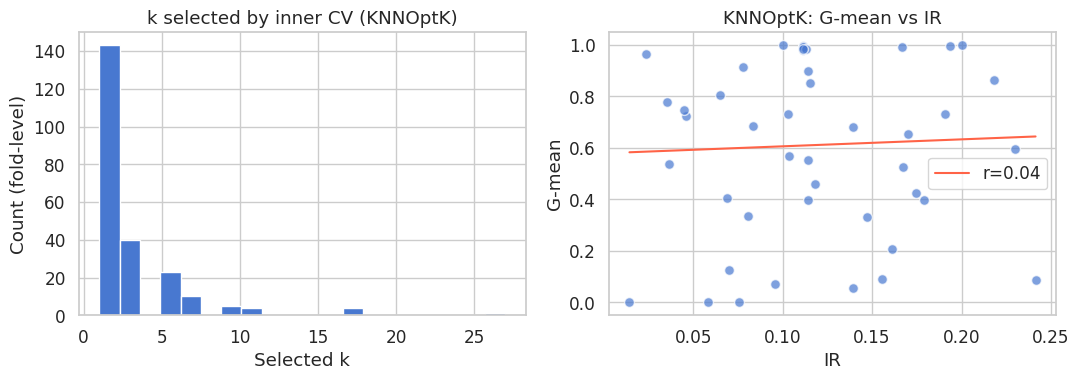

KNNOptK selected k=1 in 62.2% of folds


In [10]:
# Best-k distribution
per_ds_optk = opt_k_df.groupby("dataset")[["IR","f1","geometric_mean","roc_auc","best_k"]].mean().round(4)
per_ds_optk.to_csv(TAB_DIR / "opt_k_per_dataset.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(opt_k_df["best_k"], bins=20, edgecolor="white")
axes[0].set(xlabel="Selected k", ylabel="Count (fold-level)", title="k selected by inner CV (KNNOptK)")

axes[1].scatter(per_ds_optk["IR"], per_ds_optk["geometric_mean"], alpha=0.7, edgecolors="white", s=50)
slope, intercept, r, p, _ = sp_stats.linregress(per_ds_optk["IR"], per_ds_optk["geometric_mean"])
x_line = np.linspace(per_ds_optk["IR"].min(), per_ds_optk["IR"].max(), 100)
axes[1].plot(x_line, slope*x_line+intercept, color="tomato", lw=1.5, label=f"r={r:.2f}")
axes[1].set(xlabel="IR", ylabel="G-mean", title="KNNOptK: G-mean vs IR"); axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "optk_analysis.png", dpi=150)
plt.show()
print(f"KNNOptK selected k=1 in {(opt_k_df['best_k']==1).mean()*100:.1f}% of folds")

---
## 6. Phase 1 Conclusions

**Bias confirmed at two levels:**
- **Surface:** F1, G-mean, and ROC-AUC are negatively correlated with IR — performance degrades
  systematically as imbalance grows, even with data-driven k selection.
- **Structural:** the root cause is an unfair comparison — rank-1 minority vs rank-1 majority
  conflates geometric proximity with class density. The expected minority rank-1 distance inflates
  as $r^{1/d}$ relative to majority. A fair comparison requires majority rank-$r$.

**Key empirical finding:** KNNOptK selects k=1 in ~62% of folds, confirming that the
globally optimal k for imbalanced data is as local as possible — but even k=1 does not fix
the structural bias, it only minimises the majority-vote effect.

**Motivation for Phase 2:** the bias is not a k-selection problem — it is a rank-comparison
problem. Phase 2 addresses it directly via KNNFairRank.